In [1]:
import numpy as np
# %matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import pickle
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('ggplot')
import sys
import numpy

### SETUP COPULA
# sys.path.append("D:/NPC")
#sys.path.append("C:/Users/alessandro/Documents/GitHub/NPC")
sys.path.append("/Users/safaai/Library/CloudStorage/OneDrive-CompTech/Houman_Work/NPC")
import tensorflow as tf
#gpu_devices = tf.config.experimental.list_physical_devices('GPU')
#device = gpu_devices[0]
# tf.config.experimental.set_memory_growth(device, True)
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import sys
from classes.objects import *
from vine_tree.tree_op import *

from scipy import stats
import pickle

###########

from param.generate_rvine import *
from param.margin_fit import *
from param.margin_op import *
from param.copula_fit import *
from param.cond_copula import *
from pre_proc.preparation import prep_cop
from pred.prediction import*
from sampling.vine_sample import *
from info.info_estimation import vine_entropy

#gpu_available = tf.test.is_gpu_available('GPU')
#gpu_available = tf.config.list_physical_devices('GPU')
#print(gpu_available)
#print(tf.test.is_gpu_available('GPU:0'))
#tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#print(device_lib.list_local_devices())

In [2]:
#### Generate random matrix

cases = 3000        ### Number of samples
vine_type = 'c-vine' # or 'd-vine' or 'c-vine'
# method = 'random'
method = 'matrix'  # or 'r_matrix'  only with r-vine
binning = False
n_bin = 3
dim = 8                # Dimension of the vine for random r-vine or c-vine or d-vine


if vine_type == 'r-vine':
    
    if method == 'matrix':
        
        ######### REGULAR MATRIX
        r_matrix = np.array([[2, 0, 0, 0, 0],
                             [5, 3, 0, 0, 0],
                             [4, 5, 1, 0, 0],
                             [1, 4, 5, 4, 0],
                             [3, 1, 4, 5, 5]])
        
#         r_matrix = np.array([[3, 0, 0, 0],
#                              [1, 4, 0, 0],
#                              [2, 1, 2, 0],
#                              [4, 2, 1, 1]])
        
#         r_matrix = np.array([[3, 0, 0],
#                              [2, 2, 0],
#                              [1, 1, 1]])

        print(r_matrix)
        
    elif method == 'random':
        
        ##### RANDOM R-MATRIX
        r_matrix, ind_vine, nodes, E = random_r_matrix_gen(dim)
        print(r_matrix)

    E, ind_vine, nodes, matrix_edges = prepare_regular(r_matrix)
    print('matrix_edges',matrix_edges)
    
    ## DEFINE MARGINS
#     margin_fam1 = ['norm','gamma','norm','gamma','norm']
#     theta_fam1 = [[0,1],[2,4],[0,1],[2,4],[0,1]]
    margin_fam1 = ['norm','norm','norm','norm','norm']
    theta_fam1 = [[0,1],[0,1],[0,1],[0,1],[0,1]]
    is_cont1 = [True,True,True,True,True]

    margin_vine = []
    for i in range(0,len(margin_fam1),1):
        mar_p = margin_obj(margin_fam1[i], theta_fam1[i], is_cont1[i])
        margin_vine.append(mar_p)

    for i in range(0,len(margin_fam1),1):
        print(margin_vine[i].dist, end =' ')
        print(margin_vine[i].theta, end =' ')
    
    ######################## DEFINE COPULAS  ###################
    if not binning:
        
#         margin_cop1 = [['gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]
        
#         theta_cop1 = [[0.3, 0.5, 0.7, 0.8],
#                       [0.5, 0.8, 0.4],
#                       [0.5, 0.3],
#                       [0.9]]

#         margin_cop1 = [['gaussian','gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]
        
#         theta_cop1 = [[0.3, 0.5, 0.7, 0.8, -0.8],
#                       [0.5, 0.8, 0.4, -0.2],
#                       [0.5, 0.3, -0.7],
#                       [0.9, 0.6],
#                       [0.5]]
        
        margin_cop1 = [['gaussian','student','gaussian','gaussian','student','gaussian','student'],
                    ['gaussian','student','gaussian','gaussian','student','gaussian'],
                    ['gaussian','student','gaussian','gaussian','student'],
                    ['gaussian','gaussian','gaussian','gaussian'],
                    ['gaussian','gaussian','gaussian'],
                    ['gaussian','gaussian'],
                    ['gaussian']]

        theta_cop1 = [[0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8, [0,-0.2]],
                        [0.9, [0,0.2], -0.9, -0.8, [0,-0.2], -0.8],
                        [0.9, [0,0.2], -0.9, -0.8, [0,-0.2]],
                        [0.3, 0.7, 0.4, 0.1],
                        [0.2, -0.3, 0.1],
                        [0.2, 0.2],
                        [0.1]]
        
#         margin_cop1 = [['gaussian','gaussian','gaussian'],
#                        ['gaussian','gaussian'],
#                        ['gaussian']]

#         theta_cop1 = [[0.7, 0.8, 0.9],
#                       [0.6, 0.5],
#                       [0.7]]

        # margin_cop1 = [['clayton','clayton','clayton'],
        #                ['clayton','clayton'],
        #                ['clayton']]

        # theta_cop1 = [[3.7, 4.8, 5.9],
        #               [6.6, 2.5],
        #               [5.7]]
    else:
        
        margin_cop1 = [['gaussian','gaussian','gaussian','gaussian'],
                       [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
                      [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
                      [['gaussian','gaussian','gaussian']]]

        theta_cop1 = [[0.3, 0.5, 0.7, 0.8],
                      [[0.3, 0.4, 0.5],[0.6, 0.7, 0.8],[0.2, 0.3, 0.4]],
                      [[0.3, 0.4, 0.5],[0.3, 0.5, 0.9]],
                      [[0.2, 0.5, 0.9]]] #0.2,0.5,0.9
        
#         margin_cop1 = [['gaussian','gaussian','gaussian'],
#                        [['gaussian','gaussian','gaussian'],['gaussian','gaussian','gaussian']],
#                       [['gaussian','gaussian','gaussian']]]

#         theta_cop1 = [[0.7, 0.8, 0.9],
#                       [[0.3, 0.4, 0.5],[0.6, 0.7, 0.8]],
#                       [[0.2, 0.5, 0.9]]]

#         margin_cop1 = [['gaussian','gaussian'],
#                       [['gaussian','gaussian','gaussian']]]

#         theta_cop1 = [[0.7, 0.8],
#                       [[0.2, 0.5, 0.9]]]


    d = len(r_matrix)
    cop_vine = []
    for tr in range(0,d-1,1):
        cop_vine1 = []
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                cop_p = cop_par_obj(margin_cop1[tr][col],theta_cop1[tr][col])
                cop_vine1.append(cop_p)
            else:
                cop_vine11 = []
                for bb in range(0,n_bin,1):
                    cop_p = cop_par_obj(margin_cop1[tr][col][bb],theta_cop1[tr][col][bb])
                    cop_vine11.append(cop_p)
                cop_vine1.append(cop_vine11)
        cop_vine.append(cop_vine1)

    for tr in range(0,d-1,1):
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                print('edge: {} '.format(matrix_edges[tr][col]), 'cop family: {}'.format(cop_vine[tr][col].family), 'theta: {}'.format(cop_vine[tr][col].theta))
            else:
                for bb in range(0,n_bin,1):
                    print('edge: {} '.format(matrix_edges[tr][col]),'bin: {} '.format(bb), 'cop family: {}'.format(cop_vine[tr][col][bb].family), 'theta: {}'.format(cop_vine[tr][col][bb].theta))

    ################# IF YOU WANT TO USE C-VINE OR D-VINE    ################################### 
elif (vine_type == 'c-vine') | (vine_type == 'd-vine'):
    
    
    r_matrix, ind_vine, nodes, matrix_edges = prepare_vine(vine_type, dim)

    print(r_matrix)

    binning = False
    n_bin = 3
    
    ########## DEFINE MARGINS
    
    margin_vine = []
    for i in range(0,dim,1):
        mar_p = margin_obj('norm', [0,1], True)
        margin_vine.append(mar_p)

    for i in range(0,dim,1):
        print(margin_vine[i].dist, end =' ')
        print(margin_vine[i].theta, end =' ')

    ############## DEFINE COPULAS
    # NN = 0
    # tr = 0
    # cop_vine = []
    # for i in range(dim,1,-1):
    #     cop_vine1 = []
    #     for j in range(0,i-1,1):
    #         if (tr == 0) | (binning == False):
    # #             if tr == NN:
    # #                 cop_p = cop_par_obj('ind',[])  #
    # #                 cop_vine1.append(cop_p)
    # #             else:
    #             # cop_p = cop_par_obj('clayton',4.5)  #
    #             cop_p = cop_par_obj('student',[0,0.2])  #
    #             cop_vine1.append(cop_p)
    #         else:
    #             cop_vine11 = []
    #             for bb in range(0,n_bin,1):
    #                 cop_p = cop_par_obj('gaussian',0.9)
    #                 cop_vine11.append(cop_p)
    #             cop_vine1.append(cop_vine11)
    #     cop_vine.append(cop_vine1)
    #     tr += 1
    
    margin_cop1 = [['gaussian','student','gaussian','gaussian','student','gaussian','student'],
                    ['gaussian','student','gaussian','gaussian','student','gaussian'],
                    ['gaussian','student','gaussian','gaussian','student'],
                    ['gaussian','gaussian','gaussian','gaussian'],
                    ['gaussian','gaussian','gaussian'],
                    ['gaussian','gaussian'],
                    ['gaussian']]

    theta_cop1 = [[0.9, [0,0.2], -0.9, -0.8, [0,0.2], -0.8, [0,0.2]],
                    [0.9, [0,0.2], -0.9, -0.8, [0,0.2], -0.8],
                    [0.9, [0,0.2], -0.9, -0.8, [0,0.2]],
                    [0.3, 0.7, 0.4, 0.1],
                    [0.2, -0.3, 0.1],
                    [0.2, 0.2],
                    [0.1]]
    
    d = len(r_matrix)
    cop_vine = []
    for tr in range(0,d-1,1):
        cop_vine1 = []
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                cop_p = cop_par_obj(margin_cop1[tr][col],theta_cop1[tr][col])
                cop_vine1.append(cop_p)
            else:
                cop_vine11 = []
                for bb in range(0,n_bin,1):
                    cop_p = cop_par_obj(margin_cop1[tr][col][bb],theta_cop1[tr][col][bb])
                    cop_vine11.append(cop_p)
                cop_vine1.append(cop_vine11)
        cop_vine.append(cop_vine1)

    # # NN = 0
    # tr = 0
    # cop_vine = []
    # for i in range(dim,1,-1):
    #     cop_vine1 = []
    #     for j in range(0,i-1,1):
    #         if (tr == 0) | (binning == False):
    # #             if tr == NN:
    # #                 cop_p = cop_par_obj('ind',[])  #
    # #                 cop_vine1.append(cop_p)
    # #             else:
    #             cop_p = cop_par_obj(margin_cop1[tr][j],theta_cop1[tr][j])  #
    #             cop_vine1.append(cop_p)
    #         else:
    #             cop_vine11 = []
    #             for bb in range(0,n_bin,1):
    #                 cop_p = cop_par_obj(margin_cop1[tr][j][bb],theta_cop1[tr][j][bb])
    #                 cop_vine11.append(cop_p)
    #             cop_vine1.append(cop_vine11)
    #     cop_vine.append(cop_vine1)
    #     tr += 1

    d = len(r_matrix)
    for tr in range(0,d-1,1):
        for col in range(0,d-1-tr,1):
            if (tr == 0) | (binning == False):
                print('edge: {} '.format(matrix_edges[tr][col]), 'cop family: {}'.format(cop_vine[tr][col].family), 'theta: {}'.format(cop_vine[tr][col].theta))
            else:
                for bb in range(0,n_bin,1):
                    print('edge: {} '.format(matrix_edges[tr][col]),'bin: {} '.format(bb), 'cop family: {}'.format(cop_vine[tr][col][bb].family), 'theta: {}'.format(cop_vine[tr][col][bb].theta))

# if binning == True:
#     exc = tf.math.floormod(cases,n_bin)
#     cases = cases - exc

sample1, v, v_flip, tau_corr, tau_bins = generate_r_samples(cases, r_matrix, ind_vine, nodes, margin_vine, cop_vine, n_bin, binning)
print(sample1)

nodes:
[1 2 3 4 5 6 7 8]
edges:
['(1,2)', '(1,3)', '(1,4)', '(1,5)', '(1,6)', '(1,7)', '(1,8)']
['(2,3|1)', '(2,4|1)', '(2,5|1)', '(2,6|1)', '(2,7|1)', '(2,8|1)']
['(3,4|2,1)', '(3,5|2,1)', '(3,6|2,1)', '(3,7|2,1)', '(3,8|2,1)']
['(4,5|3,2,1)', '(4,6|3,2,1)', '(4,7|3,2,1)', '(4,8|3,2,1)']
['(5,6|4,3,2,1)', '(5,7|4,3,2,1)', '(5,8|4,3,2,1)']
['(6,7|5,4,3,2,1)', '(6,8|5,4,3,2,1)']
['(7,8|6,5,4,3,2,1)']
[[8 0 0 0 0 0 0 0]
 [7 7 0 0 0 0 0 0]
 [6 6 6 0 0 0 0 0]
 [5 5 5 5 0 0 0 0]
 [4 4 4 4 4 0 0 0]
 [3 3 3 3 3 3 0 0]
 [2 2 2 2 2 2 2 0]
 [1 1 1 1 1 1 1 1]]
norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] norm [0, 1] edge: (1,2)  cop family: gaussian theta: 0.9
edge: (1,3)  cop family: student theta: [0, 0.2]
edge: (1,4)  cop family: gaussian theta: -0.9
edge: (1,5)  cop family: gaussian theta: -0.8
edge: (1,6)  cop family: student theta: [0, 0.2]
edge: (1,7)  cop family: gaussian theta: -0.8
edge: (1,8)  cop family: student theta: [0, 0.2]
edge: (2,3|1)  cop

In [3]:
dim = 8
vine_depth = dim

mean = [0, 0, 0, 0, 0, 0, 0, 0]
f=0.2
cov = [[1, f, f, f, f, f, f, f], [f, 1, f, f, f, f, f, f], [f, f, 1, f, f, f, f, f], [f, f, f, 1, f, f, f, f], [f, f, f, f, 1, f, f, f], [f, f, f, f, f, 1, f, f], [f, f, f, f, f, f, 1, f], [f, f, f, f, f, f, f, 1]]  # diagonal covariance
#mean = [0, 0, 0]
#f=0.5
#cov = [[1, f, f], [f, 1, f], [f, f, 1]]  # diagonal covariance

#mean = [0, 0]
#f=0.95
#cov = [[1, f],[f, 1]]  # diagonal covariance
#dim=2

import matplotlib.pyplot as plt
x = np.random.multivariate_normal(mean, cov, 1000).T
sample = numpy.transpose(x)
#plt.plot(sample[:,0],sample[:,1],'b.')

x = tf.cast(x, tf.float64)
print(x.dtype)


<dtype: 'float64'>


In [4]:
#### LOAD DATA OR VINE BANDWIDTH AND MATRIX IF NEEDED
load_mat = False
load_pickle = False

if load_mat:
    mat_contents = sio.loadmat('stu_ex_01.mat') #sim_vine #sim17_10000.mat')   #X_sim17.mat')
    # print(mat_contents)
    dat = mat_contents.get('x') #X_sim17
    dat = np.array(dat,np.float64)

    pdf_cop = mat_contents.get('pdf_cop') #X_sim17
    pdf_cop = np.array(pdf_cop,np.float32)
    
elif load_pickle:
    pickle_in = open("dict_pickle","rb")
    dict_save = pickle.load(pickle_in)
    vine = dict_save["vine"]
    sample = dict_save["data"]
    vine_depth = 20

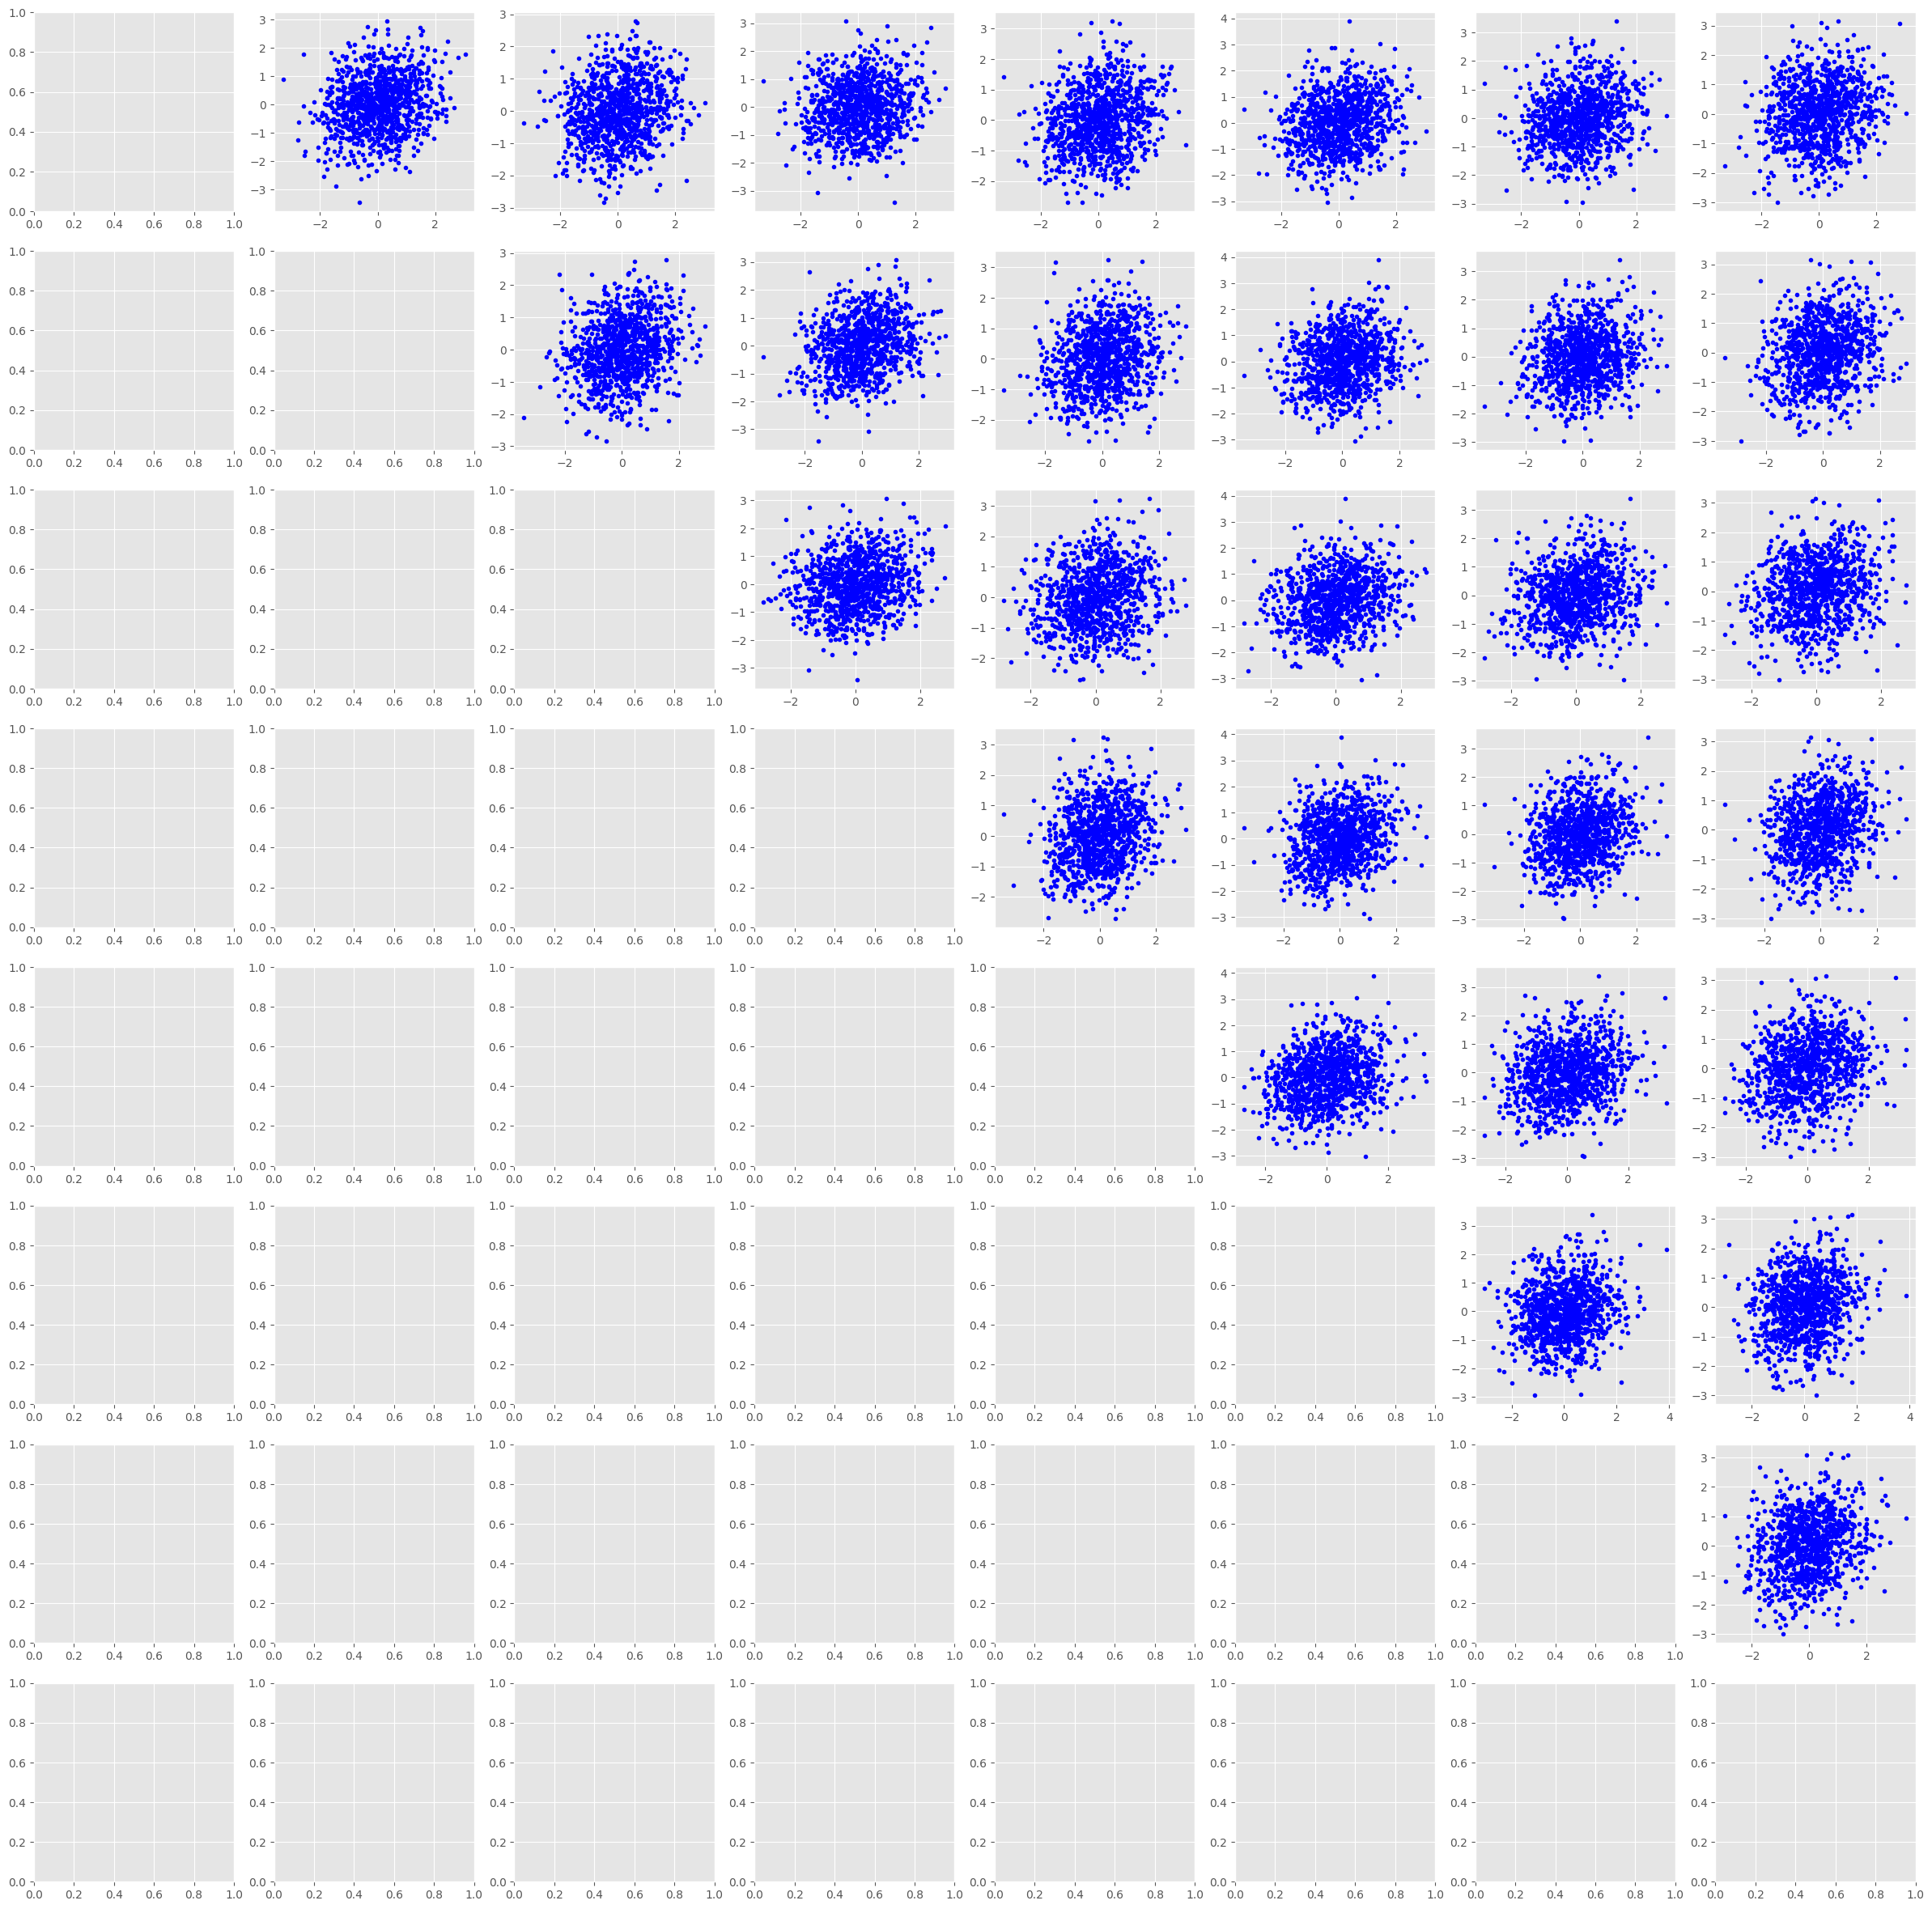

In [5]:
fig, axs = plt.subplots(dim, dim,figsize=(30,30))
for i in range(0,dim,1):
    for j in range(i+1,dim,1):
        #axs[i,j].plot(xx[:,i],xx[:,j],'r.')    
        axs[i,j].plot(sample[:,i],sample[:,j],'b.')    
        # axs[i,j].set_title(str(max(xx[:,i])))

In [6]:
################### DEFINE VINE #################

# vine_type = "r-vine"
# method = 'optimal' #'matrix' #'matrix' 
vine_type = "d-vine"
method = 'random' #'matrix' #'matrix' 
families = "kercop"
knots = 50

vine_depth = len(r_matrix)

# vine_depth = 20 #len(r_matrix)

margin_vine = []
for i in range(0,vine_depth,1):
    mar_p = margin_obj('norm', [0,1], True)
    margin_vine.append(mar_p)
    
vine = vine_obj_bin(vine_type, families, vine_depth, margin_vine, knots, method, r_matrix)

nodes:
[1 2 3 4 5 6 7 8]
edges:
['(1,2)', '(2,3)', '(3,4)', '(4,5)', '(5,6)', '(6,7)', '(7,8)']
['(1,3|2)', '(2,4|3)', '(3,5|4)', '(4,6|5)', '(5,7|6)', '(6,8|7)']
['(1,4|2,3)', '(2,5|3,4)', '(3,6|4,5)', '(4,7|5,6)', '(5,8|6,7)']
['(1,5|2,3,4)', '(2,6|3,4,5)', '(3,7|4,5,6)', '(4,8|5,6,7)']
['(1,6|2,3,4,5)', '(2,7|3,4,5,6)', '(3,8|4,5,6,7)']
['(1,7|2,3,4,5,6)', '(2,8|3,4,5,6,7)']
['(1,8|2,3,4,5,6,7)']


In [7]:
print(vine.margin[1].ker)

None


print(margin_vine[1].ker)

### Vine fitting

General parameters:
- parallel: True or False           (Fit in parallel each level)
- binning: True or False            (It can be True only if parallel is False)
- param: True or False              (Parametric or Non-parametric)
- vine_depth: any                   (Max level of vine to fit)

Parametric parameters:
- param_families: ["ind","gaussian","student","clayton","claytonrot90"]   (Decide which parametric families to fit)

Non-parametric parameters:
- opt_method: 'LL1' or 'LL2'

Binning parameters:
- n_bin: any                        (Number of bins)

In [8]:
param = False
binning = False
n_bin = 3

## Make data divisible for bins and k-fold
# x = dat # sample  #dat
x = sample #[:,ind1]
x = np.array(x,np.float64)

if binning == True:
    if param == False:
        exc = tf.math.floormod(tf.shape(x)[0],n_bin*5)
    else:
        exc = tf.math.floormod(tf.shape(x)[0],n_bin)
    x = x[:tf.shape(x)[0]-exc,:]
else:
    if param == False:
        exc = tf.math.floormod(tf.shape(x)[0],5)
        x = x[:tf.shape(x)[0]-exc,:]

## Prepare copula

sort_n = 'rand' #'rand'
e = prep_cop(x, vine, sort_n)
print(e)
print(vine)

[[ 0.14523135 -0.24496401  2.06369955 ... -0.59579061  0.5464063
  -1.09671414]
 [-0.68131612 -1.15907245 -0.68530577 ... -0.18127076 -0.98443322
  -0.66723738]
 [-0.75277367 -0.90776134  0.7133604  ...  1.46165574 -0.39115269
   1.97899668]
 ...
 [ 0.05474839 -0.04702178  1.06434505 ... -0.71997619  0.03243474
  -0.30887529]
 [ 0.01307587  1.01271642  0.0983531  ...  1.16594872  0.15491794
   0.40693892]
 [-0.52699076 -0.46887125 -0.79998647 ...  0.22121875  0.73631342
   1.44906207]]


In [9]:
#str1 = 'D:/NPC/HS_test_vine.mat'
#sio.savemat(str1,{'data':x,'sample':sample})

print(vine.margin[1].ker)

[-2.44964006e-01 -1.15907245e+00 -9.07761339e-01  3.19243892e-01
 -3.95279674e-01  3.68155320e-01  1.22844676e-01 -7.07946175e-02
 -5.99104659e-02 -1.19467049e+00  1.32973219e+00  7.54657230e-01
  6.08043690e-01 -1.48080669e-01 -5.86139876e-01 -6.52370593e-03
  7.40967736e-01  1.95233423e-01  7.26629041e-01 -5.63101472e-01
 -1.16826568e+00 -2.95879043e-01  1.92495717e-01 -2.52381380e-01
 -2.45203198e-01  1.27769777e+00 -5.51661584e-01  1.71933227e+00
 -1.21280634e-01 -6.51414931e-01 -1.17936804e-01  2.65939309e+00
 -7.37632128e-01  1.83723948e+00 -7.75441104e-01 -2.05167530e-01
  2.05976538e-01  8.31529286e-01  5.22949936e-01  4.37011097e-01
 -7.33113471e-02 -5.46199673e-01  7.15524961e-02  5.76332218e-01
  3.58972590e-01 -1.04555356e+00 -4.47903697e-01 -4.49937631e-01
 -1.63475983e+00 -1.28026320e+00 -4.15824852e-02 -8.39745849e-01
  9.50128961e-01  3.83773372e-01 -7.61319049e-01 -1.11419146e+00
  9.88773005e-01 -1.62296484e+00  1.28615165e+00 -1.53312218e+00
 -7.45489698e-01  2.93422

In [10]:
print(x.dtype)

float64


In [11]:
### FITTING
# Parameters:
# - Data: x
# - Parallel: True or False
# - Bandwidth optimization: LL1 or LL2
# - Binning: True or false.    It can be True only if parallel is false
# - n_bin: Select the number of bins
# parallel = False

gen_dict = {'parallel':False, 'binning':binning, 'param':param, 'vine_depth':vine_depth+1, 'fitted':False}  #vine_depth
par_dict = {'param_families':["ind","gaussian"]}  #["ind","gaussian","student","clayton","claytonrot90"]
npc_dict = {'opt_method':'LL1','batch_paral':5}
bin_dict = {'n_bin':n_bin}

vine.fit(x,gen_dict,npc_dict,par_dict,bin_dict)

time_fit: 4.282919583
time_fit: 1.9634641250000016
time_fit: 3.3539294159999997
time_fit: 1.1659678749999998
time_fit: 3.4285343339999983
time_fit: 0.3058847920000005
time_fit: 0.9779307079999988
time_fit: 2.098593790999999
time_fit: 1.0364770830000012
time_fit: 1.246172166000001
time_fit: 2.540032417000006
time_fit: 0.8860698749999969
time_fit: 0.8993629169999977
time_fit: 1.2131106250000059
time_fit: 2.192048833000001
time_fit: 1.5042102499999999
time_fit: 1.469276542000003
time_fit: 0.8223482499999974
time_fit: 2.0037777499999976
time_fit: 0.9011847080000024
time_fit: 0.8901127500000001
time_fit: 1.1634312919999985
time_fit: 1.7009487090000022
time_fit: 3.4226455000000016
time_fit: 1.2804071660000034
time_fit: 2.5772201249999966
time_fit: 1.158264583999994
time_fit: 1.7683093329999906


In [12]:
print(x.shape)
print(vine.r_matrix)

(1000, 8)
[[8 0 0 0 0 0 0 0]
 [1 7 0 0 0 0 0 0]
 [2 1 6 0 0 0 0 0]
 [3 2 1 5 0 0 0 0]
 [4 3 2 1 4 0 0 0]
 [5 4 3 2 1 3 0 0]
 [6 5 4 3 2 1 2 0]
 [7 6 5 4 3 2 1 1]]


In [13]:
knots = tf.constant(50, dtype=tf.int32)
u_1, ex_u = mk_grid(knots,'float64')

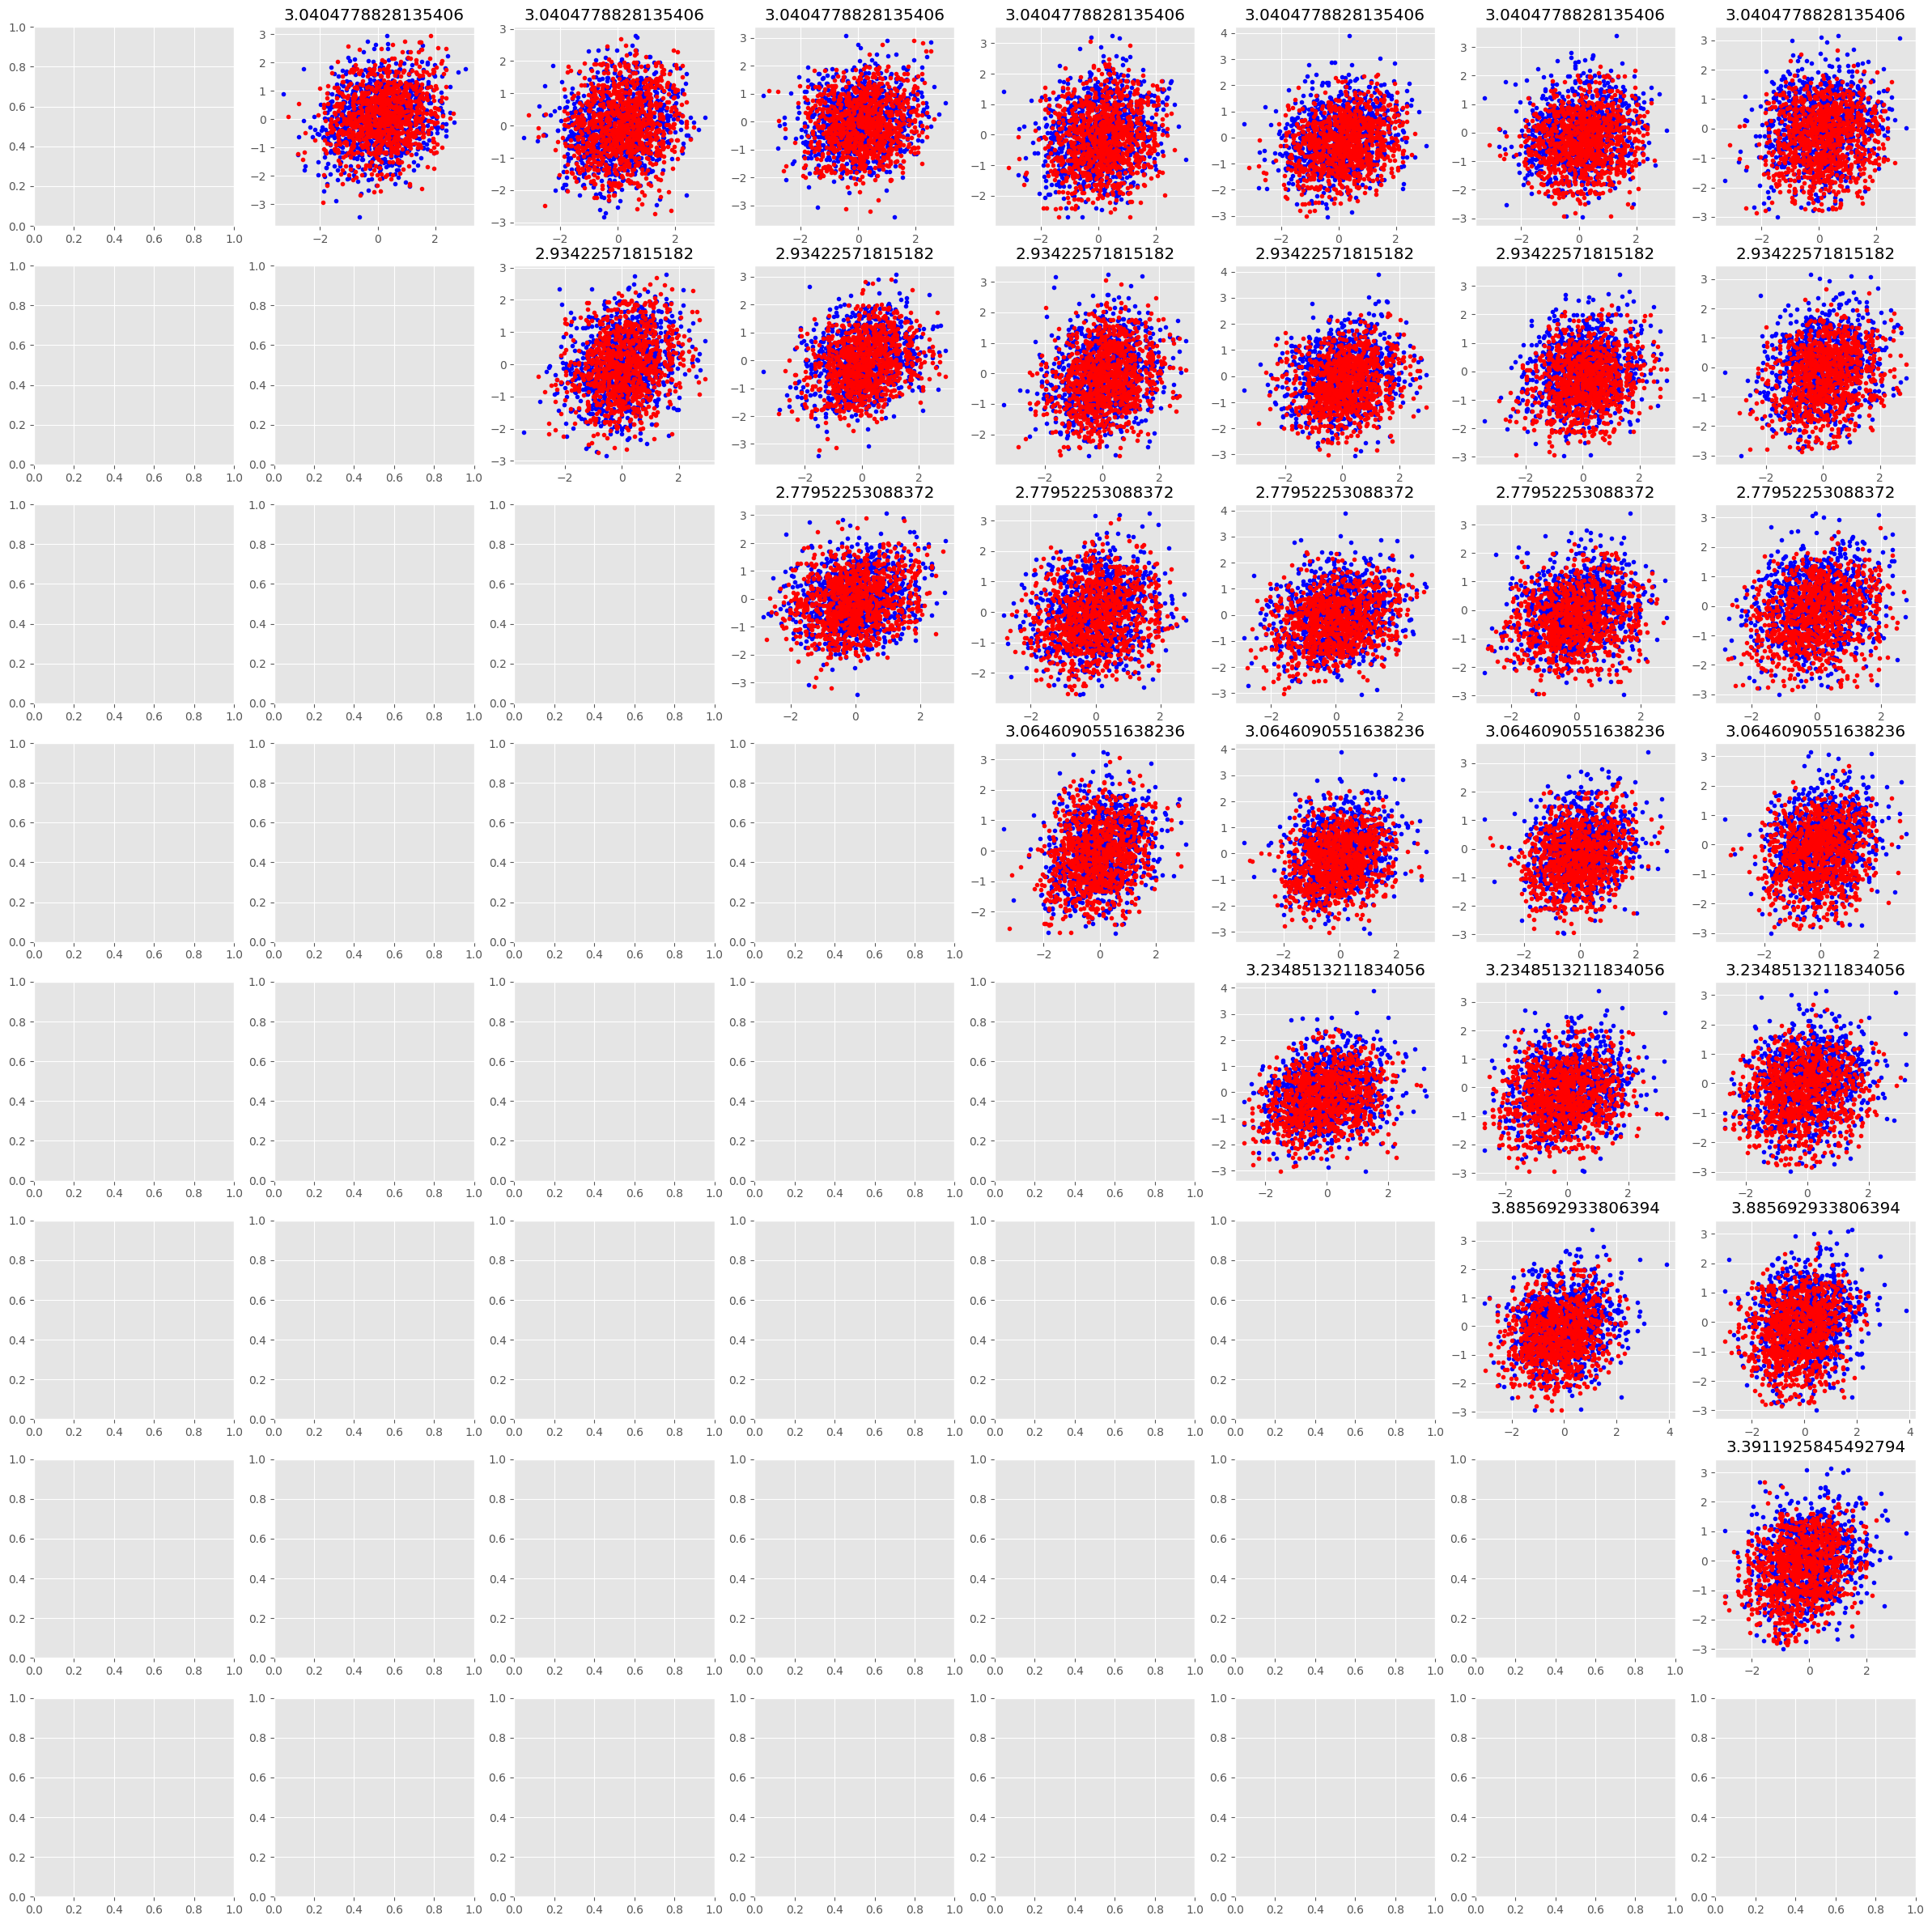

In [14]:
sample3 ,u, pd, sd = vine_copula_sample(vine,1000)
#sample3 = pd
xx = x
#xx = u

fig, axs = plt.subplots(vine_depth, vine_depth,figsize=(30,30))
for i in range(0,vine_depth,1):
    for j in range(i+1,vine_depth,1):
        axs[i,j].plot(xx[:,i],xx[:,j],'b.')    
        axs[i,j].plot(sample3[:,i],sample3[:,j],'r.')    
        axs[i,j].set_title(str(max(xx[:,i])))

# fig.savefig('dv1.eps', bbox_inches='tight', dpi=150)

[-3.44610518e+00 -2.88002127e+00 -2.63579980e+00 -2.54602976e+00
 -2.51659594e+00 -2.35681706e+00 -2.33610287e+00 -2.27653154e+00
 -2.26894624e+00 -2.20959229e+00 -2.18828678e+00 -2.13975172e+00
 -2.13185608e+00 -2.12083362e+00 -2.11463612e+00 -2.08648578e+00
 -2.07368785e+00 -2.04317088e+00 -2.03782410e+00 -2.02489332e+00
 -1.97824041e+00 -1.96119483e+00 -1.95890881e+00 -1.94814999e+00
 -1.94217681e+00 -1.93475721e+00 -1.93172112e+00 -1.88945692e+00
 -1.85161998e+00 -1.79975231e+00 -1.79690792e+00 -1.79222745e+00
 -1.79138983e+00 -1.78430927e+00 -1.78007606e+00 -1.77992370e+00
 -1.76283286e+00 -1.75778253e+00 -1.72869985e+00 -1.72139268e+00
 -1.69443953e+00 -1.67948260e+00 -1.67831796e+00 -1.67604674e+00
 -1.65648921e+00 -1.64990170e+00 -1.64976418e+00 -1.64675242e+00
 -1.64036543e+00 -1.63475983e+00 -1.63363861e+00 -1.62883373e+00
 -1.62296484e+00 -1.61643335e+00 -1.58275436e+00 -1.55889778e+00
 -1.55258834e+00 -1.53312218e+00 -1.51698181e+00 -1.51648813e+00
 -1.50390006e+00 -1.49962

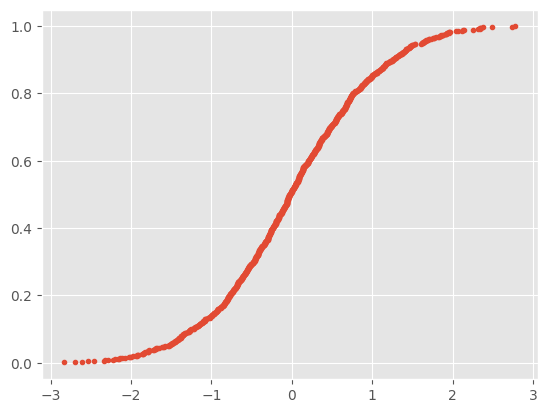

In [15]:
plt.figure()
plt.plot(sd[:,2],pd[:,2],'.')
print(sd[:,1])

#### Vine evaluation

In [22]:
########### CREATE POINTS FOR EVALUATION
exp_dim = 1
dim = 1
points = create_points(x,dim,exp_dim)
#print(points)
# p, p_cop, logp = vine.evaluation(points)
p, p_cop, logp = vine.evaluation(x)

#r = vine.evaluation(x)
#mm = margin_obj(x, dist, theta, is_cont)
vine.method

'random'

#### Predict response

In [17]:
############### PREDICT VINE ##################
dim = 0
exp_dim = 100

p, y_ml, y_em = predict_vine(x,vine,dim,exp_dim)

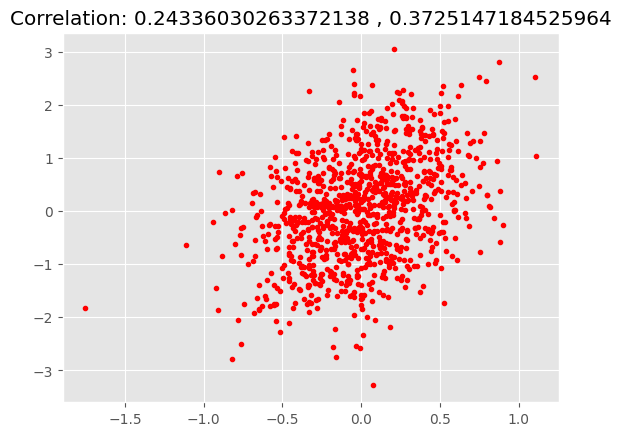

In [18]:
from scipy import stats
corr = stats.pearsonr(x[:,dim], y_ml)
corre = stats.pearsonr(x[:,dim], y_em)

plt.figure()
#plt.plot(y_ml, x[:,dim], 'g.')
plt.plot(y_em, x[:,dim], 'r.')
plt.title('Correlation: ' + str(corr[0]) + ' , ' + str(corre[0]))
plt.show()

In [19]:
def vine_entropy(vine,info_dict):
    alpha = info_dict['alpha']
    cases = info_dict['cases'] #number of samples in each iteration 
    max_iter = info_dict['iterations']
    d = vine.n_cop

    norm_dis = tfd.Normal(loc=0., scale=1.) 
    conf = norm_dis.quantile(1-alpha)
    tim = 0  #Add as parameter if you want to change it

    mo = 0 
    varsum1 = 0 
    infoc1 = 0
    cond_entr = 0
    entr_f2 = 0
    entr_f3 = 0
    stderr1 = 1e+6
    stderr2 = 1e+6 
    stderr3 = 1e+6 
    stderr_tot = 1e+6
    erreps = 1e-3
    
    MI_XY=numpy.zeros(max_iter,numpy.float)
    MI_SING=numpy.zeros(max_iter,numpy.float)
    EN_XY=numpy.zeros(max_iter,numpy.float)
    EN_X1=numpy.zeros(max_iter,numpy.float)
    EN_X2=numpy.zeros(max_iter,numpy.float)

    while ((stderr1 >= erreps)  | (stderr_tot >= erreps) ) & (mo < max_iter):
        mo = mo+1
        if vine.param == False:

            sample , u, p1, p2 = vine_copula_sample(vine,cases)
            #sample = x

            #x = np.random.multivariate_normal(mean, cov, 2000).T
            #sample = numpy.transpose(x)

            p, p_copula, log_marg_f= vine.evaluation(sample)

            ## Compute cond entr.
            p_cond = np.exp(np.log(p_copula.numpy()))
            #- np.log(p_f2.numpy()))
            
            log2_cond = np.log(p_cond)
            log2_cond[p_cond == 0] = 0 

            cond_12=np.mean(log2_cond);
            cond_entr = cond_entr + ( np.mean(log2_cond) - cond_entr) / mo  #tf.math.reduce_mean

            varsum1 = varsum1 + np.sum((log2_cond - cond_entr)**2)
            stderr1 = conf * np.sqrt(varsum1 / (mo * cases * (mo * cases - 1)))
            
            print(cond_entr)
            
            EN_XY[mo-1] = cond_entr
        else:
            sample = vine_cop_par_sample(vine,cases)

            # Compute pdf of samples
            p, pcop = vine.evaluation(sample)
            
            log2pp = np.log2(pcop.numpy())
            log2pp[pcop == 0] = 0 

            infoc1 = infoc1 + ( np.mean(log2pp) - infoc1) / mo
            varsum1 = varsum1 + np.sum((log2pp - infoc1)**2)
            stderr1 = conf * np.sqrt(varsum1 / (mo * cases * (mo * cases - 1)))
    
    return EN_XY

#### Vine entropy estimation

In [20]:
#info_dict = {'cases':2000, 'iterations':10, 'alpha': 0.05}
#MI = vine_entropy(vine,info_dict)
info_dict = {'cases':10000, 'iterations':20, 'alpha': 0.05}
EN_XY = vine_entropy(vine,info_dict)
plt.plot(EN_XY)

AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [ ]:
import math

analytic_entropy = -0.5 * np.log(np.linalg.det(cov))+dim/2*(1+np.log(2*math.pi))
analytic_entropyP = -0.5 * np.log(1-f**2)


print(analytic_entropy,analytic_entropyP)

In [ ]:
import math

analytic_entropy = -0.5 * np.log(np.linalg.det(cov))+dim/2*(1+np.log(2*math.pi))
analytic_entropyP = -0.5 * np.log(1-f**2)


print(analytic_entropy,analytic_entropyP)

In [ ]:
print(vine.r_matrix)
print(vine.ind_vine)